In [1]:
# ---------------
#  T o  -   D o :
# ---------------

# (*) START OMNI - execute experiments one-by-one




In [152]:
import matplotlib.pyplot as plt
import pandas            as pd
import numpy             as np
import matplotlib        as mpl
import copy

from   scipy.interpolate import interp1d
from   dataclasses       import dataclass, field, fields
from   itertools         import accumulate, chain
from   openpyxl          import load_workbook, Workbook

# My stuff
from doe_sampling.doe_sampler         import DoESampler

import exp_generation.profile_gen_helper_funcs

from exp_generation.profile_gen      import DefineProcessParameter
from exp_generation.profile_gen      import ProfileCreator
from exp_generation.profile_gen      import ExperimentProfileParameters
from exp_generation.profile_gen      import ExperimentProfileStorage
from exp_generation.profile_gen      import ExpComponentGen
from exp_generation.profile_gen      import ProfileGenerator

from exp_generation.pump_calibration import PumpRateConverter


mpl.rcParams.update({'font.size': 7,'axes.labelsize': 7,'axes.titlesize': 7,'xtick.labelsize': 7,'ytick.labelsize': 7,'legend.fontsize': 7,
                     'grid.alpha': 0.5, 'grid.linewidth': 0.7,'grid.linestyle': '-', 'xtick.minor.visible': True, 'ytick.minor.visible': True,})
#mpl.use("TkAgg")

as_pump_cal_location   = r"FILES\pump_calibration\expttsd1_AS.csv"
solu_pump_cal_location = r"FILES\pump_calibration\expttsd1_SOLU.csv"
solv_pump_cal_location = r"FILES\pump_calibration\expttsd1_SOLV.csv"

as_rate_converter           = PumpRateConverter(as_pump_cal_location,   'File  W: AS ',     'File R: Mass ')  
solution_rate_converter     = PumpRateConverter(solu_pump_cal_location, 'P01:Value (Setpt)','File R: Mass ')  
solvent_rate_converter      = PumpRateConverter(solv_pump_cal_location, 'P01:Value (Setpt)','File R: Mass ')  
cleaning_sol_rate_converter = PumpRateConverter(solv_pump_cal_location, 'P01:Value (Setpt)','File R: Mass ') 

doe_sampler          = DoESampler()                                                        # ...generating the settings for Experiments
component_gen        = ExpComponentGen(exp_generation.profile_gen_helper_funcs)            # ...functions for experiment section generation
exp_par              = ExperimentProfileParameters()                                       # ...storing the parameters for DoE profile generation
profiles             = ProfileGenerator(exp_par, component_gen, exp_generation.profile_gen_helper_funcs)       
exp_storage          = ExperimentProfileStorage(as_rate_converter, solution_rate_converter, solvent_rate_converter,  cleaning_sol_rate_converter) 


#%matplotlib qt

In [241]:

class ExperimentCreator():
    def __init__(self, doe_sampler, component_gen, exp_par, profiles, exp_storage):
        self.exp_par       = exp_par
        self.doe_sampler   = doe_sampler
        self.component_gen = component_gen
        self.profiles      = profiles
        self.exp_storage   = exp_storage
        
        
        
        # 3. Set the weights and the number of samples to take if 'not Factorial' design
        self.dimensions   = self.doe_sampler.dim_counter(exp_par)
        self.weights      = self.dimensions*[1] # weights to ExperimentProfileParameters !! - not working currently
        self.if_sampling  = False 
    
        self.samples      = 1        # to be set by user !!
        self.Fract        = 0        # to be set by user !!
        self.TYPE         = 'GREEDY' # to be set by user !!

        self.DoE_val = dict()
        self.DoE_samples = np.array([])
        self.DoE_sampled_scaled = np.array([])
        self.plotting_axes = []
        self.plotting_figs = []
    
    def set_doe_settings(self,exp_par, samples, Fract = 0, Type = 'GREEDY'):    

        # 0. initial inputs
        self.samples = samples
        self.Fract   = Fract
        self.TYPE    = Type
        
        # 1. Correct the settings, so that if a section is false, all of its settings are neglected
        self.exp_par       = exp_generation.profile_gen_helper_funcs.exp_par_condition_corr(self.exp_par)
        
        # 2. Count the dimensions subject to change
        self.dimensions  = self.doe_sampler.dim_counter(exp_par)
        
        if self.dimensions < 1 or self.samples < 2:
            print(f'Dimensions:{self.dimensions}, samples {self.samples} !')
            print(f'Generating {self.samples} sample(s) using the identical, default settings !')
            self.if_sampling  = False 
        elif self.Fract > 2 and self.TYPE == 'FACT':
            print('Select Fract to be: 0>=Fract>=2}')
        else:
            print(f'Dimensions:{self.dimensions}, samples {self.samples} !')
            self.if_sampling = True

    def generate_experiments(self):
        # build the experimental DoE --> all profiles for each experiment    
        
        for i in range(self.samples):
            print(self.if_sampling)
            if self.if_sampling: # sampling is True then take the optimal samples otherwise just use the default .values
                # Generate DoE either Factorial or Optimal sampling-based
                self.DoE_samples = self.doe_sampler.doe_generator(1,self.samples,self.dimensions,self.weights,self.TYPE,self.Fract)[0]
                
                # Illustrate sampled points
                illustrate_samples = False
                
                self.DoE_sampled_scaled = self.doe_sampler.scaler(self.DoE_samples)
                
                for f in fields(self.exp_par):
                    if f.type.__name__ == "DefineProcessParameter" and getattr(self.exp_par, f.name).if_in_doe:
                        dim_index = 0
                        param = getattr(self.exp_par, f.name)
                        new_value = self.doe_sampler.descaler(self.DoE_sampled_scaled[i,dim_index],param) # get samples
                            
                        if param.if_only_minmax: # if if_only_minmax == True don't ge\t the samples, only take min or max alternating
                            if i % 2 == 0:
                                setattr(param, "value", param.min_val)
                                self.DoE_val[f.name] = [param.min_val]                    
                            else:
                                setattr(param, "value", param.max_val)
                                self.DoE_val[f.name] = [param.max_val]
                                
                        else: # if if_only_minmax == False take the sampled value
                            setattr(param, "value", new_value[0])
                            self.DoE_val[f.name] = [new_value[0]]
                            
                    if self.exp_par.if_ARR:
                        self.exp_par.ARR = self.exp_par.ARR_types[i%len(self.exp_par.ARR_types)]
                
                dim_index += 1
        
            self.exp_storage.add_experiment(f'exp{i+1}', self.profiles.generate_profiles()[0],self.profiles.generate_profiles()[1])
            
            # Store the changed parameters of the DoE
            self.exp_storage.add_doe_stage( f'exp{i+1}', pd.DataFrame(self.DoE_val)) # this is empty when only one sample is taken
            
        for i in range(self.samples):
            exp_key = f'exp{i+1}'
            self.exp_storage.profile_omni[exp_key] = exp_storage.profile_omni[exp_key].drop_duplicates()
            
    def plot_sampled_points(self):
        if self.DoE_samples.size:
            self.doe_sampler.two_dim_plotter([self.doe_sampler.scaler(self.DoE_samples)],[self.TYPE])
            self.doe_sampler.three_dim_plotter(self.doe_sampler.scaler(self.DoE_samples))
        else:
            print('Generate samples first')

    def export_generated_expts(self,loc_to_save_expts):
        
        for i in range(self.samples):
            
            DAT = pd.DataFrame(self.exp_storage.profile_omni[f'exp{i+1}'])
            
            try:
                with pd.ExcelWriter(loc_to_save_expts, engine="openpyxl", mode="a") as writer:
                    DAT.to_excel(writer, sheet_name=f"exp{i+1}", index=False)
            except:
                with pd.ExcelWriter(loc_to_save_expts, engine="openpyxl", mode="w") as writer:
                    DAT.to_excel(writer, sheet_name=f"exp{i+1}", index=False)

    def export_OMNI_expts(self,loc_to_save_expts):

        mapping = {
        'T': 'MAIN-TEMP',
        'AS': 'AS',
        'stirring_rate': 'MAIN-STR',
        'solution': 'SOLUTION',
        'solvent': 'SOLVENT',
        'seed': 'SEED',
        'clean_sol':'CLEANING',
        'valve_state': 'VALVE',
        'stirring_rate_seed': 'SEED-STIR',
        'stirring_rate_sol':'SOLUTION-STIR'}
        
        reordered_exps = {}
        
        for i in range(self.samples):
            reordered_data = {}
            for key, value in mapping.items():
                reordered_data[f't_{value}'] = self.exp_storage.profile_omni[f'exp{i+1}'][f't_{key}']
                reordered_data[value] = self.exp_storage.profile_omni[f'exp{i+1}'][key]
                
            reordered_data = pd.DataFrame(reordered_data)
            reordered_exps[f'exp{i+1}'] =  reordered_data

        header = pd.read_csv(r"FILES\helper_files_for_omni_export\headers_OMNI.csv")
        HEAD = pd.DataFrame(header)
        HEAD = HEAD.apply(lambda col: pd.to_numeric(col, errors="coerce").fillna(col))

        loc_to_save_expts = loc_to_save_expts+r'\agrprofiles.xlsx'
        
        try:
            wb = load_workbook(loc_to_save_expts)
            for sheet in wb.worksheets[1:]:
                wb.remove(ws)
                wb.create_sheet(title=f"subexp{1}")
                wb.save(loc_to_save_expts)
        except Exception as e:
            wb = Workbook()
            default_sheet = wb.active
            wb.remove(default_sheet)
            wb.create_sheet(title=f"subexp{1}")
            wb.save(loc_to_save_expts)
            
        for i in range(self.samples):
            
            DAT = pd.DataFrame(reordered_exps[f"exp{i+1}"])
            
            with pd.ExcelWriter(loc_to_save_expts, engine="openpyxl", mode="a",if_sheet_exists='replace') as writer:
                DAT.to_excel(writer,  sheet_name=f"subexp{i+1}", index=False,startrow=7,header=False)
            with pd.ExcelWriter(loc_to_save_expts, engine="openpyxl", mode="a",if_sheet_exists='overlay') as writer:    
                HEAD.to_excel(writer, sheet_name=f"subexp{i+1}", index=False,startrow=0,header=False)

        
    def plot_doe_experiments(self):
        
        for i in range(self.samples):
            fig, ax = plt.subplots(figsize=(4,2))
            ax_AS   = ax.twinx()
            
            ax_AS.spines['right'].set_color('red')

            ax_seed = ax.twinx()
            ax_seed.spines['right'].set_position(('outward', 40))
            ax_seed.spines['right'].set_color('blue')
            
            ax_solution   = ax.twinx()
            ax_solution.spines['right'].set_position(('outward', 80))
            ax_solution.spines['right'].set_color('orange')
            
            ax_solv   = ax.twinx()
            ax_solv.spines['right'].set_position(('outward', 120))
            ax_solv.spines['right'].set_color('magenta')
            
            ax_cl   = ax.twinx()
            ax_cl.spines['right'].set_position(('outward', 160))
            ax_cl.spines['right'].set_color('cyan')
            
            ax_valve   = ax.twinx()
            ax_valve.spines['right'].set_position(('outward', 200))
            ax_valve.spines['right'].set_color('yellow')
            
            self.exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='T'   ,       color = 'k',      ax = ax,         linestyle ='-.' , label='T',        ylabel='Temperature [C]')
            self.exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='AS'  ,       color = 'r',      ax = ax_AS,      linestyle ='--' , label='AS',       ylabel='AS addition rate [rpm]')
            self.exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='seed',       color = 'b',      ax = ax_seed,    linestyle = '-' , label='seed',     ylabel='wet seed addition rate [rpm]')
            self.exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='solution',   color = 'orange', ax = ax_solution,linestyle = '-.', label='solution', ylabel='solution addition rate [rpm]')
            self.exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='solvent',    color = 'magenta',ax = ax_solv,    linestyle = '-.', label='solvent',  ylabel='solvent addition rate [rpm]')
            self.exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='clean_sol',  color = 'cyan',   ax = ax_cl,      linestyle = '-.', label='cleaning', ylabel='aceton addition rate [ml/h]')
            self.exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='valve_state',color = 'yellow', ax = ax_valve,   linestyle = '-' , label='valve'   , ylabel='Valve stage [1 or 0]')
            
            ax.set_title(f'Exp{i+1}')
            
            ax.legend(loc='best', bbox_to_anchor=(1.0, 1.25),fontsize=8)
            ax_AS.legend(loc='best', bbox_to_anchor=(1.2, 1.25),fontsize=8)
            ax_solution.legend(loc='best', bbox_to_anchor=(0.85, 1.25),fontsize=8)
            ax_solv.legend(loc='best', bbox_to_anchor=(0.2, 1.25),fontsize=8)
            ax_cl.legend(loc='best', bbox_to_anchor=(1.5, 1.25),fontsize=8)
            ax_seed.legend(loc='best', bbox_to_anchor=(0.4, 1.25),fontsize=8)
            ax_valve.legend(loc='best', bbox_to_anchor=(1.8, 1.25),fontsize=8)
            
            ax.grid(alpha=0.2)
            #plt.show()
            self.plotting_figs.append(fig)
            self.plotting_axes.append({'T':ax, 'AS': ax_AS,'seed': ax_seed,'solution': ax_solution,'solvent': ax_solv,'clean_sol': ax_cl,'valve_state': ax_valve})

In [246]:
# ---------------------------------
# I. DEFINE DATA FOR DoE Generation
# ---------------------------------

# 0. Define parameters for DoE (min, max, active parameters)
# by changing exp_par.X

exp_par.if_ARR = False       
exp_par.ARR = 'AS'              

#exp_par.if_AS  = False               
exp_par.AS_add_time.if_in_doe = True
exp_par.AS_add_time.value     = 4.31        
exp_par.if_cool_in_exp        = True      
exp_par.t_cool.if_in_doe      = True     
exp_par.T_diss.value          = 75
exp_par.T_diss.if_in_doe      = True

exp_par.if_diss_initial       = True        
exp_par.t_diss.value          = 0.01
exp_par.t_h_0.value           = 0.5
exp_par.T_0.value             = 65

#exp_par.aceton_boil_out_T  = 20
exp_par.if_boil               = True
exp_par.if_solv_rinse         = False
exp_par.if_cleaning           = True
exp_par.if_opening            = True

#exp_par.seed.if_in_doe     = False
exp_par.t_h_seed.value        = 0.5
exp_par.seed.value            = 0.347153014

exp_par.t_h_clean.value     = 0.5
exp_par.t_eq.value          = 2
exp_par.t_h_solution.value  = 0.1
exp_par.wait_after_exp      = 1
exp_par.t_before_open_valve = 0.1
exp_par.clean_sol.value     = 300
exp_par.solvent.value       = 300
exp_par.solution.value      = 200 + 12.2025
exp_par.t_h_clean.value     = 0.1



Dimensions:5, samples 2 !
True
True


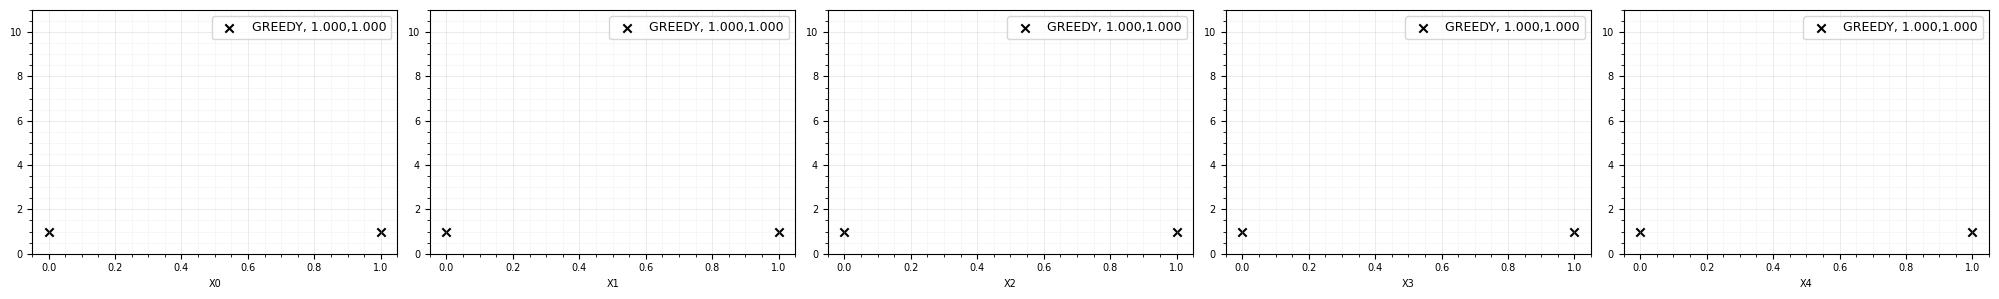

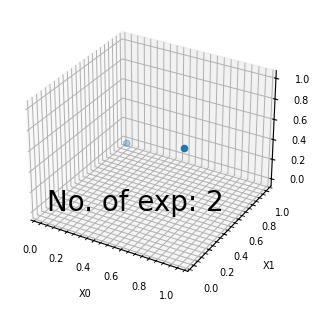

In [247]:
create_expts = ExperimentCreator(doe_sampler, component_gen, exp_par, profiles, exp_storage)
create_expts.set_doe_settings(exp_par,2)
create_expts.generate_experiments()
create_expts.plot_sampled_points()
#create_expts.plot_doe_experiments()

In [254]:
create_expts.export_OMNI_expts(r"C:\Users\abotondo\OneDrive - purdue.edu\ECNDATA\Desktop")